# Feu vert, feu jaune, feu rouge
Modèle de risque pour des prêts personnels (données Lending Club).

In [18]:
import os
os.listdir("../data")

['lending_club_info.csv', 'lending_club_loan_two.csv']

## 1. Chargement des données
On charge les prêts et le dictionnaire des variables.

In [19]:
import pandas as pd

df = pd.read_csv("../data/lending_club_loan_two.csv")
info = pd.read_csv("../data/lending_club_info.csv")

print(df.shape)
df.head()

(396030, 27)


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650"


Taux de défaut global et période couverte.

In [20]:
print(df["loan_status"].value_counts(normalize=True))

dates = pd.to_datetime(df["issue_d"], format="%b-%Y")
print("Earliest:", dates.min(), " Latest:", dates.max())

loan_status
Fully Paid     0.803871
Charged Off    0.196129
Name: proportion, dtype: float64
Earliest: 2007-06-01 00:00:00  Latest: 2016-12-01 00:00:00


Taux de défaut par année.

In [21]:
df["year"] = dates.dt.year
df["default"] = (df["loan_status"] == "Charged Off").astype(int)

df.groupby("year").agg(
    n_loans=("default", "size"),
    default_rate=("default", "mean")
).round(3)

,n_loans,default_rate
year,,
2007,195,0.164
2008,1240,0.158
2009,3826,0.123
2010,9258,0.132
2011,17435,0.152
2012,41202,0.165
2013,97662,0.157
2014,102860,0.231
2015,94264,0.249


Taux de défaut par année et par durée du prêt.

In [22]:
df.groupby(["year", "term"])["default"].mean().unstack().round(3)

term,36 months,60 months
year,,
2007,0.164,NaN
2008,0.158,NaN
2009,0.123,NaN
2010,0.104,0.210
2011,0.106,0.239
2012,0.134,0.337
2013,0.122,0.323
2014,0.189,0.349
2015,0.207,0.350


## 2. Sélection des prêts
On garde les prêts de 36 mois émis entre 2010 et 2014, pour éviter les prêts pas encore terminés.

In [23]:
df["term"] = df["term"].str.strip()

data = df[(df["term"] == "36 months") & (df["year"].between(2010, 2014))].copy()

print(data.shape)
data.groupby("year")["default"].agg(["size", "mean"]).round(3)

(209445, 29)


,size,mean
year,,
2010,6820,0.104
2011,11311,0.106
2012,35006,0.134
2013,80366,0.122
2014,75942,0.189


## 3. Séparation dans le temps
Entraînement : 2010–2012. Test : 2013. Les prêts de 2014 ne sont pas encore assez terminés.

In [24]:
train = data[data["year"] <= 2012].copy()
test = data[data["year"] == 2013].copy()

print("Train :", train.shape, "| taux de défaut :", round(train["default"].mean(), 3))
print("Test  :", test.shape, "| taux de défaut :", round(test["default"].mean(), 3))

Train : (53137, 29) | taux de défaut : 0.124
Test  : (80366, 29) | taux de défaut : 0.122


## 4. Variables à exclure
On retire la cible, les colonnes inutiles ou constantes, et la note de Lending Club (pour ne pas copier son modèle).

In [25]:
target = "default"

drop_cols = [
    "loan_status", "default", "year", "issue_d", "term",
    "emp_title", "title", "address", "initial_list_status",
    "grade", "sub_grade", "int_rate", "installment",
    "application_type",
]

y_train = train[target]
y_test = test[target]

## 5. Création de variables
Ancienneté au travail en chiffres, durée de l'historique de crédit, prêt / revenu.

In [26]:
import numpy as np

def prepare(d):
    d = d.copy()

    d["emp_length"] = (
        d["emp_length"]
        .replace({"< 1 year": "0", "10+ years": "10"})
        .str.extract(r"(\d+)")[0]
        .astype(float)
    )

    issue = pd.to_datetime(d["issue_d"], format="%b-%Y")
    first = pd.to_datetime(d["earliest_cr_line"], format="%b-%Y")
    d["credit_hist_years"] = (issue - first).dt.days / 365.25

    income = d["annual_inc"].replace(0, np.nan)
    d["loan_to_income"] = d["loan_amnt"] / income

    main = ["MORTGAGE", "RENT", "OWN"]
    d["home_ownership"] = d["home_ownership"].where(d["home_ownership"].isin(main), "OTHER")

    return d.drop(columns=drop_cols + ["earliest_cr_line"])

X_train = prepare(train)
X_test = prepare(test)

X_train.head()

,loan_amnt,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,credit_hist_years,loan_to_income
7,13000.0,10.0,RENT,46000.0,Not Verified,credit_card,26.87,11.0,0.0,13425.0,64.5,15.0,0.0,0.0,18.001369,0.282609
9,26300.0,3.0,MORTGAGE,115000.0,Verified,debt_consolidation,23.69,13.0,0.0,22171.0,82.4,37.0,1.0,0.0,14.332649,0.228696
14,25975.0,9.0,MORTGAGE,65000.0,Verified,small_business,9.18,9.0,0.0,5140.0,7.2,35.0,6.0,0.0,11.419576,0.399615
22,4200.0,5.0,OWN,24000.0,Not Verified,other,4.80,6.0,0.0,0.0,0.0,7.0,NaN,0.0,4.665298,0.175000
25,6000.0,2.0,RENT,46680.0,Not Verified,medical,6.56,9.0,0.0,4370.0,40.1,10.0,NaN,0.0,6.499658,0.128535


## 6. Valeurs manquantes
On remplace les valeurs manquantes par la médiane de l'entraînement seulement.

In [27]:
num_cols = X_train.select_dtypes("number").columns

print("Valeurs manquantes avant :")
print(X_train[num_cols].isna().sum()[lambda s: s > 0])

medians = X_train[num_cols].median()
X_train[num_cols] = X_train[num_cols].fillna(medians)
X_test[num_cols] = X_test[num_cols].fillna(medians)

print("\nValeurs manquantes après :", X_train[num_cols].isna().sum().sum())

Valeurs manquantes avant :
emp_length     2043
revol_util       53
mort_acc      22968
dtype: int64

Valeurs manquantes après : 0


## 7. Vérification
On vérifie la taille des données et les variables qui restent.

In [28]:
print("X_train :", X_train.shape, "| X_test :", X_test.shape)
print("\nVariables :", list(X_train.columns))

cat_cols = X_train.select_dtypes(exclude="number").columns
for c in cat_cols:
    print(f"\n{c} :", X_train[c].unique())

X_train : (53137, 16) | X_test : (80366, 16)

Variables : ['loan_amnt', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'credit_hist_years', 'loan_to_income']

home_ownership : <ArrowStringArray>
['RENT', 'MORTGAGE', 'OWN', 'OTHER']
Length: 4, dtype: str

verification_status : <ArrowStringArray>
['Not Verified', 'Verified', 'Source Verified']
Length: 3, dtype: str

purpose : <ArrowStringArray>
[       'credit_card', 'debt_consolidation',     'small_business',
              'other',            'medical',              'house',
   'home_improvement',     'major_purchase',                'car',
        'educational',           'vacation',            'wedding',
             'moving',   'renewable_energy']
Length: 14, dtype: str


## 8. Encodage des catégories
On transforme les variables texte en colonnes 0/1.

In [29]:
X_train_enc = pd.get_dummies(X_train, drop_first=True, dtype=int)
X_test_enc = pd.get_dummies(X_test, drop_first=True, dtype=int)

X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print(X_train_enc.shape, X_test_enc.shape)

(53137, 31) (80366, 31)


## 9. Premier modèle : régression logistique
Modèle simple et transparent, la base des cartes de pointage des banques.

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logit = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000)),
])

logit.fit(X_train_enc, y_train)
print("Modèle entraîné.")

Modèle entraîné.


## 10. Pouvoir de discrimination
AUC et Gini : le modèle sépare-t-il les bons et les mauvais clients ?

In [31]:
from sklearn.metrics import roc_auc_score

p_train = logit.predict_proba(X_train_enc)[:, 1]
p_test = logit.predict_proba(X_test_enc)[:, 1]

for name, y, p in [("Train", y_train, p_train), ("Test", y_test, p_test)]:
    auc = roc_auc_score(y, p)
    print(f"{name} | AUC : {auc:.3f} | Gini : {2*auc - 1:.3f}")

Train | AUC : 0.635 | Gini : 0.269
Test | AUC : 0.620 | Gini : 0.240


**Résultat :** AUC test 0,620 (Gini 0,240). Petit écart avec l'entraînement : pas de surapprentissage. Pouvoir modeste, car il n'y a pas de score de crédit (FICO) dans les données.

## 11. Calibration
Le taux de défaut prédit est-il proche du taux réel ?

In [32]:
print("PD moyenne prédite :", round(p_test.mean(), 3))
print("Taux de défaut réel :", round(y_test.mean(), 3))

calib = pd.DataFrame({
    "decile": pd.qcut(p_test, 10, labels=False),
    "pd_predite": p_test,
    "defaut_reel": y_test.values,
})
calib.groupby("decile").mean().round(3)

PD moyenne prédite : 0.128
Taux de défaut réel : 0.122


,pd_predite,defaut_reel
decile,,
0,0.054,0.053
1,0.077,0.074
2,0.091,0.084
3,0.103,0.097
4,0.115,0.119
5,0.128,0.123
6,0.141,0.138
7,0.157,0.152
8,0.180,0.174


**Résultat :** PD prédite 12,8 % contre 12,2 % réel. Le modèle surestime un peu le risque, mais les déciles sont proches et bien ordonnés.

## 12. Effet des variables
Coefficient positif : plus de risque. Négatif : moins de risque.

In [33]:
coefs = pd.Series(
    logit.named_steps["model"].coef_[0],
    index=X_train_enc.columns,
).sort_values()

coefs.round(3)

annual_inc                            -0.156
loan_amnt                             -0.121
revol_bal                             -0.105
purpose_credit_card                   -0.087
total_acc                             -0.086
credit_hist_years                     -0.014
purpose_major_purchase                -0.010
purpose_wedding                       -0.005
purpose_educational                    0.017
verification_status_Verified           0.018
verification_status_Source Verified    0.023
home_ownership_OTHER                   0.023
mort_acc                               0.026
emp_length                             0.029
pub_rec_bankruptcies                   0.030
purpose_house                          0.031
home_ownership_OWN                     0.034
pub_rec                                0.039
purpose_vacation                       0.044
purpose_renewable_energy               0.045
purpose_home_improvement               0.046
purpose_moving                         0.048
purpose_me

Liste complète des coefficients.

In [34]:
print(coefs.round(3).to_string())

annual_inc                            -0.156
loan_amnt                             -0.121
revol_bal                             -0.105
purpose_credit_card                   -0.087
total_acc                             -0.086
credit_hist_years                     -0.014
purpose_major_purchase                -0.010
purpose_wedding                       -0.005
purpose_educational                    0.017
verification_status_Verified           0.018
verification_status_Source Verified    0.023
home_ownership_OTHER                   0.023
mort_acc                               0.026
emp_length                             0.029
pub_rec_bankruptcies                   0.030
purpose_house                          0.031
home_ownership_OWN                     0.034
pub_rec                                0.039
purpose_vacation                       0.044
purpose_renewable_energy               0.045
purpose_home_improvement               0.046
purpose_moving                         0.048
purpose_me

## 13. Corrélations entre variables
On vérifie si certaines variables disent presque la même chose.

In [35]:
cols = ["loan_amnt", "annual_inc", "loan_to_income", "revol_bal", "revol_util", "open_acc", "total_acc"]
X_train[cols].corr().round(2)

,loan_amnt,annual_inc,loan_to_income,revol_bal,revol_util,open_acc,total_acc
loan_amnt,1.00,0.27,0.57,0.33,0.07,0.18,0.23
annual_inc,0.27,1.00,-0.23,0.34,0.01,0.13,0.20
loan_to_income,0.57,-0.23,1.00,0.01,0.06,-0.02,-0.08
revol_bal,0.33,0.34,0.01,1.00,0.27,0.27,0.29
revol_util,0.07,0.01,0.06,0.27,1.00,-0.06,-0.06
open_acc,0.18,0.13,-0.02,0.27,-0.06,1.00,0.67
total_acc,0.23,0.20,-0.08,0.29,-0.06,0.67,1.00


## 14. Test : sans loan_amnt
Si on retire loan_amnt, le modèle reste-t-il aussi bon ? Les signes sont-ils plus logiques ?

In [36]:
def fit_logit(cols_to_drop):
    Xtr = X_train_enc.drop(columns=cols_to_drop)
    Xte = X_test_enc.drop(columns=cols_to_drop)
    m = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000)),
    ])
    m.fit(Xtr, y_train)
    auc = roc_auc_score(y_test, m.predict_proba(Xte)[:, 1])
    coefs = pd.Series(m.named_steps["model"].coef_[0], index=Xtr.columns)
    return m, auc, coefs

logit2, auc2, coefs2 = fit_logit(["loan_amnt"])

print(f"AUC test avant : {roc_auc_score(y_test, p_test):.3f}")
print(f"AUC test après : {auc2:.3f}")
print()
print(coefs2[["annual_inc", "loan_to_income", "revol_bal", "revol_util", "dti"]].round(3))

AUC test avant : 0.620
AUC test après : 0.618

annual_inc       -0.302
loan_to_income    0.151
revol_bal        -0.112
revol_util        0.292
dti               0.056
dtype: float64


**Résultat :** AUC presque identique. On garde le modèle sans loan_amnt : plus simple et plus facile à expliquer.

## 15. Deuxième modèle : LightGBM
Plusieurs petits arbres de décision. Plus flexible, mais moins transparent.

In [37]:
from lightgbm import LGBMClassifier

Xtr_lgb = X_train_enc.rename(columns=lambda c: c.replace(" ", "_"))
Xte_lgb = X_test_enc.rename(columns=lambda c: c.replace(" ", "_"))

lgb_model = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=100,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

lgb_model.fit(Xtr_lgb, y_train)
print("Modèle entraîné.")

Modèle entraîné.


## 16. Évaluation de LightGBM
Même tests : AUC, Gini et calibration.

In [38]:
p_train_lgb = lgb_model.predict_proba(Xtr_lgb)[:, 1]
p_test_lgb = lgb_model.predict_proba(Xte_lgb)[:, 1]

for name, y, p in [("Train", y_train, p_train_lgb), ("Test", y_test, p_test_lgb)]:
    auc = roc_auc_score(y, p)
    print(f"{name} | AUC : {auc:.3f} | Gini : {2*auc - 1:.3f}")

print()
print("PD moyenne prédite :", round(p_test_lgb.mean(), 3))
print("Taux de défaut réel :", round(y_test.mean(), 3))

Train | AUC : 0.800 | Gini : 0.599
Test | AUC : 0.627 | Gini : 0.254

PD moyenne prédite : 0.126
Taux de défaut réel : 0.122


## 17. Importance des variables (LightGBM)
Quelles variables aident le plus le modèle ?

In [39]:
imp = pd.Series(
    lgb_model.booster_.feature_importance(importance_type="gain"),
    index=Xtr_lgb.columns,
)
(imp / imp.sum()).sort_values(ascending=False).head(10).round(3)

revol_util           0.141
annual_inc           0.128
loan_to_income       0.105
revol_bal            0.104
credit_hist_years    0.101
dti                  0.091
loan_amnt            0.070
open_acc             0.058
total_acc            0.054
emp_length           0.038
dtype: float64

## 18. Comparaison des modèles
Champion (logistique) contre challenger (LightGBM).

In [40]:
auc_lgb = roc_auc_score(y_test, p_test_lgb)

results = pd.DataFrame({
    "Modèle": ["Logistique", "Logistique sans loan_amnt", "LightGBM"],
    "AUC test": [roc_auc_score(y_test, p_test), auc2, auc_lgb],
})
results["Gini test"] = 2 * results["AUC test"] - 1
results["Écart vs logistique"] = results["AUC test"] - results["AUC test"].iloc[0]
results.round(3)

,Modèle,AUC test,Gini test,Écart vs logistique
0,Logistique,0.620,0.240,0.000
1,Logistique sans loan_amnt,0.618,0.237,-0.001
2,LightGBM,0.627,0.254,0.007


**Résultat :** LightGBM fait à peine mieux (+0,007 d'AUC, sous notre seuil de 0,01). Le modèle retenu est la logistique sans loan_amnt : presque aussi bonne, et beaucoup plus facile à expliquer.

## 19. Raisons de chaque décision
Pour chaque client : quelles variables augmentent le plus son risque ?

In [41]:
Xte_final = X_test_enc.drop(columns=["loan_amnt"])

scaler = logit2.named_steps["scaler"]
coef = logit2.named_steps["model"].coef_[0]

p_final = logit2.predict_proba(Xte_final)[:, 1]

z = scaler.transform(Xte_final)
contrib = pd.DataFrame(z * coef, columns=Xte_final.columns, index=Xte_final.index)

def top_reasons(i, n=3):
    top = contrib.loc[i].sort_values(ascending=False).head(n)
    return pd.DataFrame({
        "contribution": top.round(3),
        "valeur du client": Xte_final.loc[i, top.index],
    })

print("Contributions calculées pour", contrib.shape[0], "clients.")

Contributions calculées pour 80366 clients.


## 20. Exemples : client le plus risqué et le moins risqué
On vérifie que les raisons ont du sens.

In [42]:
riskiest = Xte_final.index[p_final.argmax()]
safest = Xte_final.index[p_final.argmin()]

print(f"Client le plus risqué | PD = {p_final.max():.3f}")
display(top_reasons(riskiest))

print(f"Client le moins risqué | PD = {p_final.min():.3f}")
display(top_reasons(safest))

Client le plus risqué | PD = 0.741


,contribution,valeur du client
pub_rec,1.767,9.0
pub_rec_bankruptcies,1.366,8.0
purpose_other,0.320,1.0


Client le moins risqué | PD = 0.000


,contribution,valeur du client
revol_util,0.452,94.5
purpose_credit_card,0.052,0.0
mort_acc,0.044,4.0


## 21. Règle du feu de circulation
Vert : approuvé automatiquement. Rouge : refusé automatiquement. Jaune : un analyste regarde.

In [43]:
p_train_final = logit2.predict_proba(X_train_enc.drop(columns=["loan_amnt"]))[:, 1]

def traffic_light(p, green_cut, red_cut):
    return np.select([p < green_cut, p >= red_cut], ["vert", "rouge"], default="jaune")

## 22. Seuils et résultats par couleur
Vert : les 40 % les moins risqués. Rouge : les 10 % les plus risqués. Seuils fixés sur l'entraînement.

In [44]:
green_cut = np.quantile(p_train_final, 0.40)
red_cut = np.quantile(p_train_final, 0.90)
print(f"Seuil vert : PD < {green_cut:.3f} | Seuil rouge : PD ≥ {red_cut:.3f}")

feux = traffic_light(p_final, green_cut, red_cut)

summary = (
    pd.DataFrame({"feu": feux, "defaut": y_test.values})
    .groupby("feu")
    .agg(part=("defaut", "size"), taux_defaut=("defaut", "mean"))
)
summary["part"] = summary["part"] / summary["part"].sum()
summary.loc[["vert", "jaune", "rouge"]].round(3)

Seuil vert : PD < 0.106 | Seuil rouge : PD ≥ 0.192


,part,taux_defaut
feu,,
vert,0.357,0.075
jaune,0.537,0.137
rouge,0.106,0.204


## 23. Indicateurs d'affaires
Automatisation, risque du vert, défauts attrapés et bons clients refusés.

In [45]:
y = y_test.values
red = feux == "rouge"

auto_rate = np.isin(feux, ["vert", "rouge"]).mean()
green_default = y[feux == "vert"].mean()
caught = y[red].sum() / y.sum()
good_refused = (red & (y == 0)).sum() / (y == 0).sum()

print(f"Décisions automatiques : {auto_rate:.1%}")
print(f"Taux de défaut en vert : {green_default:.1%} (moyenne : {y.mean():.1%})")
print(f"Défauts attrapés par le rouge : {caught:.1%}")
print(f"Bons clients refusés par le rouge : {good_refused:.1%}")

Décisions automatiques : 46.3%
Taux de défaut en vert : 7.5% (moyenne : 12.2%)
Défauts attrapés par le rouge : 17.8%
Bons clients refusés par le rouge : 9.6%


## 24. Courbe de compromis
Plus le vert est large, plus on automatise, mais plus le vert devient risqué.

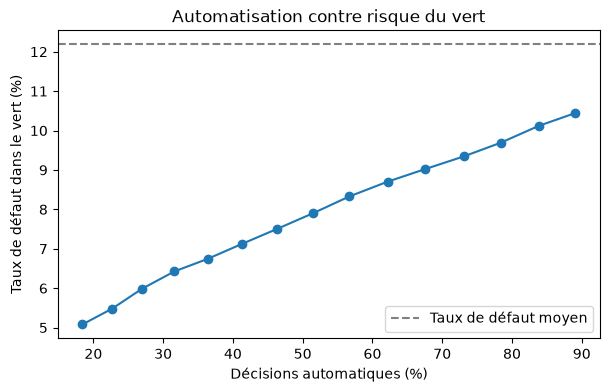

,percentile_vert,automatisation,defaut_vert
0,10,0.184,0.051
1,15,0.227,0.055
2,20,0.270,0.060
3,25,0.316,0.064
4,30,0.364,0.067
5,35,0.413,0.071
6,40,0.463,0.075
7,45,0.515,0.079
8,50,0.567,0.083
9,55,0.622,0.087


In [46]:
import matplotlib.pyplot as plt

rows = []
for q in range(10, 85, 5):
    g = np.quantile(p_train_final, q / 100)
    f = traffic_light(p_final, g, red_cut)
    green = f == "vert"
    rows.append({
        "percentile_vert": q,
        "automatisation": np.isin(f, ["vert", "rouge"]).mean(),
        "defaut_vert": y[green].mean(),
    })
curve = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curve["automatisation"] * 100, curve["defaut_vert"] * 100, marker="o")
ax.axhline(y.mean() * 100, linestyle="--", color="gray", label="Taux de défaut moyen")
ax.set_xlabel("Décisions automatiques (%)")
ax.set_ylabel("Taux de défaut dans le vert (%)")
ax.set_title("Automatisation contre risque du vert")
ax.legend()
plt.show()

curve.round(3)

## 25. Données pour le simulateur
On résume les 80 000 clients en 100 groupes de risque. Pas de données individuelles.

In [47]:
import os

rank = np.searchsorted(np.sort(p_train_final), p_final) / len(p_train_final) * 100
pct = np.clip(np.floor(rank), 0, 99).astype(int)

export = pd.DataFrame({
    "percentile": pct,
    "defaut": y,
    "montant": X_test["loan_amnt"].values,
})
export["montant_defaut"] = export["montant"] * export["defaut"]

agg = (
    export.groupby("percentile")
    .agg(
        n=("defaut", "size"),
        defauts=("defaut", "sum"),
        montant=("montant", "sum"),
        montant_defaut=("montant_defaut", "sum"),
    )
    .reindex(range(100), fill_value=0)
    .reset_index()
)
agg["pd_seuil"] = np.quantile(p_train_final, agg["percentile"] / 100)

os.makedirs("../app", exist_ok=True)
agg.to_csv("../app/simulateur.csv", index=False)

print(agg.shape, "| clients :", agg["n"].sum(), "| défauts :", agg["defauts"].sum())
agg.head()

(100, 6) | clients : 80366 | défauts : 9791


,percentile,n,defauts,montant,montant_defaut,pd_seuil
0,0,801,47,17114150.0,1237500.0,6.425474e-16
1,1,615,35,10872175.0,600475.0,3.324943e-02
2,2,558,23,8866050.0,365050.0,4.090782e-02
3,3,598,29,9200950.0,426775.0,4.578035e-02
4,4,580,33,8904275.0,606100.0,4.951020e-02
